In [1]:
# ============================================================
# JPMorgan Chase Quantitative Research Virtual Experience
# Task 3 - Probability of Default (PD) Model
# Author: Gomti Kumari
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("Task 3 and 4_Loan_Data.csv")

print("First Five Records")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

First Five Records


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0



Dataset Shape: (10000, 8)

Column Names
['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']


In [3]:
# ============================================================
# Dataset Information
# ============================================================

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
display(df.describe())

print("\nTarget Distribution")
print(df["default"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB
None

Missing Values
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Summary Statisti

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000



Target Distribution
default
0    8149
1    1851
Name: count, dtype: int64


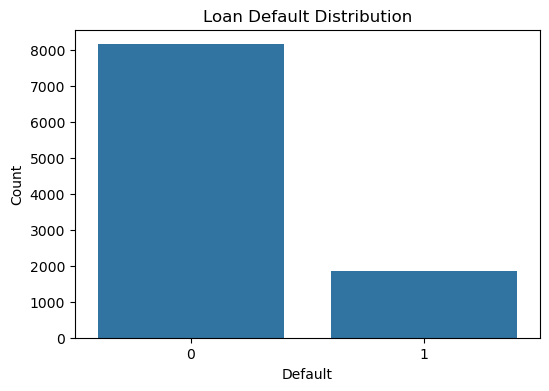

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="default",
    data=df
)

plt.title("Loan Default Distribution")

plt.xlabel("Default")

plt.ylabel("Count")

plt.show()

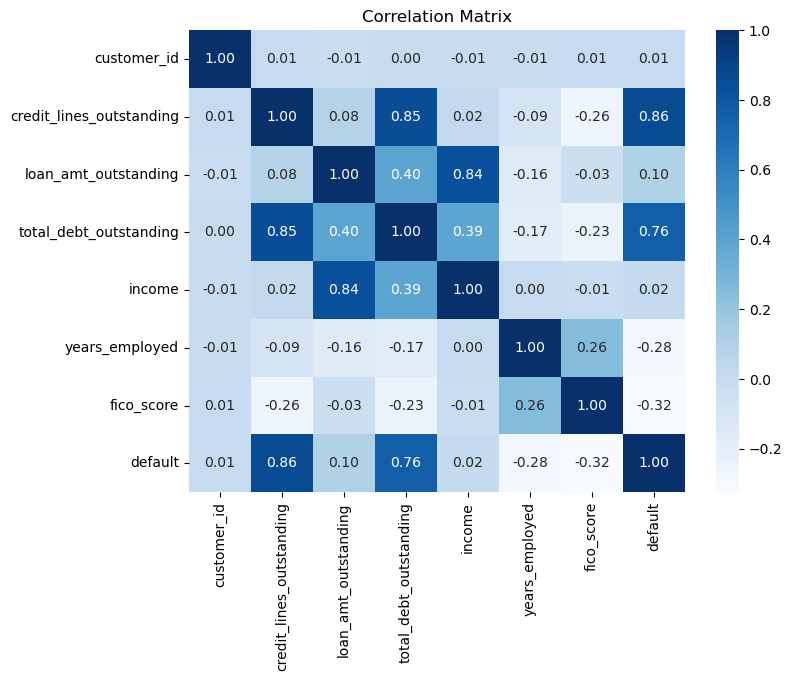

In [5]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [6]:
# ============================================================
# Feature Selection
# ============================================================

X = df.drop(
    columns=[
        "customer_id",
        "default"
    ]
)

y = df["default"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [8]:
print("Training Samples :", X_train.shape)

print("Testing Samples  :", X_test.shape)

Training Samples : (8000, 6)
Testing Samples  : (2000, 6)


TRAINING THE DATA

In [9]:
# ============================================================
# Logistic Regression Model
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [10]:
# ============================================================
# Model Predictions
# ============================================================

y_pred = logistic_model.predict(X_test)

# Probability of Default (PD)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [11]:
# ============================================================
# Model Evaluation
# ============================================================

print("Accuracy :", round(accuracy_score(y_test, y_pred),4))

print("Precision:", round(precision_score(y_test, y_pred),4))

print("Recall   :", round(recall_score(y_test, y_pred),4))

print("F1 Score :", round(f1_score(y_test, y_pred),4))

print("ROC AUC  :", round(roc_auc_score(y_test, y_prob),4))

Accuracy : 0.997
Precision: 0.9919
Recall   : 0.9919
F1 Score : 0.9919
ROC AUC  : 1.0


In [12]:
# ============================================================
# Classification Report
# ============================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       0.99      0.99      0.99       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



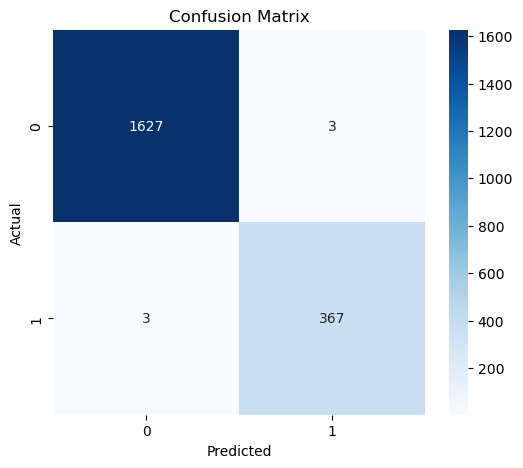

In [13]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

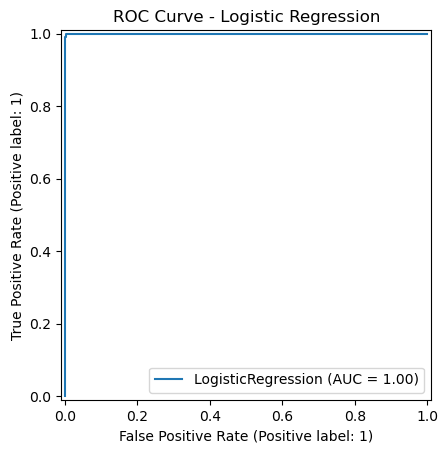

In [14]:
# ============================================================
# ROC Curve
# ============================================================

RocCurveDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [15]:
# ============================================================
# Probability of Default
# ============================================================

pd_results = X_test.copy()

pd_results["Actual_Default"] = y_test.values

pd_results["Predicted_Default"] = y_pred

pd_results["Probability_of_Default"] = y_prob

display(pd_results.head(10))

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,Actual_Default,Predicted_Default,Probability_of_Default
1187,0,3751.658863,4115.745261,69070.34542,7,706,0,0,5.686484e-22
2054,3,4377.267759,11320.947770,71546.08510,6,739,0,0,1.979657e-07
6099,1,4921.822166,10420.796650,100650.17980,6,581,0,0,6.096268e-16
7015,0,3606.449724,4868.514856,68774.96298,3,725,0,0,8.465314e-17
3119,0,2441.035518,3968.863497,48623.42864,5,603,0,0,1.821266e-15
4,1,1345.827718,1768.826187,23448.32631,6,631,0,0,4.519306e-12
2981,1,3129.304066,6304.145090,63941.28290,5,641,0,0,2.081074e-13
4594,5,5135.697135,17439.638560,61662.19356,3,580,1,1,1.000000e+00
283,1,4250.859078,6010.114775,73057.85734,7,752,0,0,9.185791e-19
8749,0,6291.117031,7050.615043,106476.82840,2,674,0,0,3.218307e-18


In [16]:
# ============================================================
# Random Forest Classifier
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [17]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [18]:
print("Random Forest Performance\n")

print("Accuracy :", round(accuracy_score(y_test, rf_pred),4))

print("Precision:", round(precision_score(y_test, rf_pred),4))

print("Recall   :", round(recall_score(y_test, rf_pred),4))

print("F1 Score :", round(f1_score(y_test, rf_pred),4))

print("ROC AUC  :", round(roc_auc_score(y_test, rf_prob),4))

Random Forest Performance

Accuracy : 0.996
Precision: 0.9918
Recall   : 0.9865
F1 Score : 0.9892
ROC AUC  : 0.9999


In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,credit_lines_outstanding,0.564684
2,total_debt_outstanding,0.295533
4,years_employed,0.051610
5,fico_score,0.042246
3,income,0.031277
1,loan_amt_outstanding,0.014650


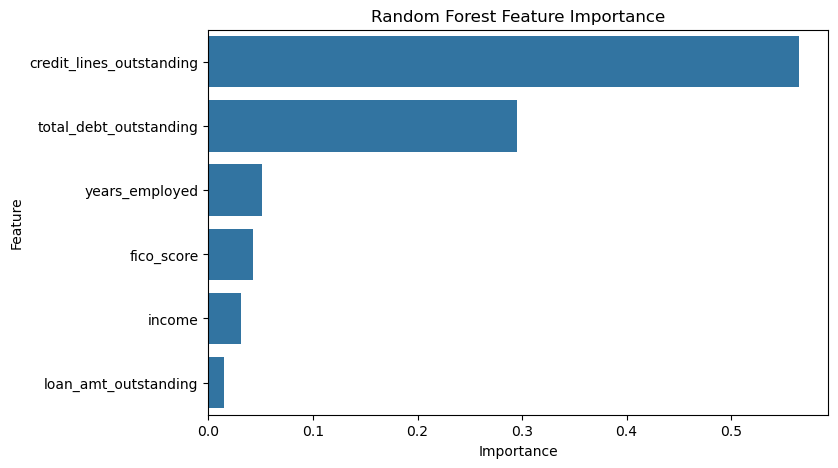

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [21]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Logistic Regression":[

        accuracy_score(y_test,y_pred),

        precision_score(y_test,y_pred),

        recall_score(y_test,y_pred),

        f1_score(y_test,y_pred),

        roc_auc_score(y_test,y_prob)

    ],

    "Random Forest":[

        accuracy_score(y_test,rf_pred),

        precision_score(y_test,rf_pred),

        recall_score(y_test,rf_pred),

        f1_score(y_test,rf_pred),

        roc_auc_score(y_test,rf_prob)

    ]

})

display(comparison)

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.997000,0.996000
1,Precision,0.991892,0.991848
2,Recall,0.991892,0.986486
3,F1 Score,0.991892,0.989160
4,ROC-AUC,0.999978,0.999893


In [22]:
# ============================================================
# Expected Loss Function
# ============================================================

RECOVERY_RATE = 0.10
LOSS_GIVEN_DEFAULT = 1 - RECOVERY_RATE


def expected_loss(customer):

    probability_default = logistic_model.predict_proba(
        customer
    )[0][1]

    exposure = customer["loan_amt_outstanding"].values[0]

    expected_loss = (
        probability_default
        * LOSS_GIVEN_DEFAULT
        * exposure
    )

    return probability_default, expected_loss

In [28]:
sample_customer = X_test.iloc[[0]]

pd_value, loss = expected_loss(sample_customer)

print(f"Probability of Default : {pd_value:.12f}")

print(f"Expected Loss : ${loss:,.2f}")

Probability of Default : 0.000000000000
Expected Loss : $0.00


In [25]:
# Predicted probabilities for all test samples
probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Index of highest-risk borrower
highest_risk_index = np.argmax(probabilities)

sample_customer = X_test.iloc[[highest_risk_index]]

pd_value, loss = expected_loss(sample_customer)

print(f"Probability of Default : {pd_value:.6f}")
print(f"Expected Loss : ${loss:,.2f}")

Probability of Default : 1.000000
Expected Loss : $5,034.49


In [26]:
# Probability of Default for all test customers
results = X_test.copy()

results["Actual Default"] = y_test.values
results["Predicted PD"] = logistic_model.predict_proba(X_test)[:, 1]

results["Expected Loss"] = (
    results["Predicted PD"]
    * 0.90
    * results["loan_amt_outstanding"]
)

# Show highest-risk borrowers
results = results.sort_values(
    by="Predicted PD",
    ascending=False
)

display(results.head(10))

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,Actual Default,Predicted PD,Expected Loss
8651,5,6834.506943,37899.41251,117584.94840,3,571,1,1.0,6151.056249
7033,5,7749.000879,35084.58138,104334.59650,1,498,1,1.0,6974.100791
6077,5,5593.882059,32487.73064,89578.59763,2,560,1,1.0,5034.493853
2133,5,8276.572480,43688.78410,121048.35320,2,701,1,1.0,7448.915232
4803,5,5783.967482,25426.98846,80660.85815,1,500,1,1.0,5205.570734
84,5,5227.129372,30897.38167,83840.58872,4,569,1,1.0,4704.416435
5460,5,8841.923630,32644.92158,115203.15190,2,541,1,1.0,7957.731267
7089,5,7989.706883,33434.40397,112065.01990,1,674,1,1.0,7190.736195
7224,5,8042.192655,31775.12918,102824.67930,2,612,1,1.0,7237.973389
7475,5,8427.592750,38215.41353,114303.69530,4,657,1,1.0,7584.833475
